<a href="https://colab.research.google.com/github/gaga0321/scRNA-aging-analysis/blob/main/scRNA_aging_analysis_bladder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scanpy
import scanpy as sc
!wget https://ndownloader.figshare.com/files/23872610 -O bladder_aging.h5ad
adata_aging = sc.read_h5ad("bladder_aging.h5ad")
print(list(adata_aging.obs.columns))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 71.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.

/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


Ages in this cohort: ['18m', '24m', '3m']

Top 5 cell types found in this tissue:
cell_ontology_class
bladder urothelial cell    1420
bladder cell               1012
Name: count, dtype: int64


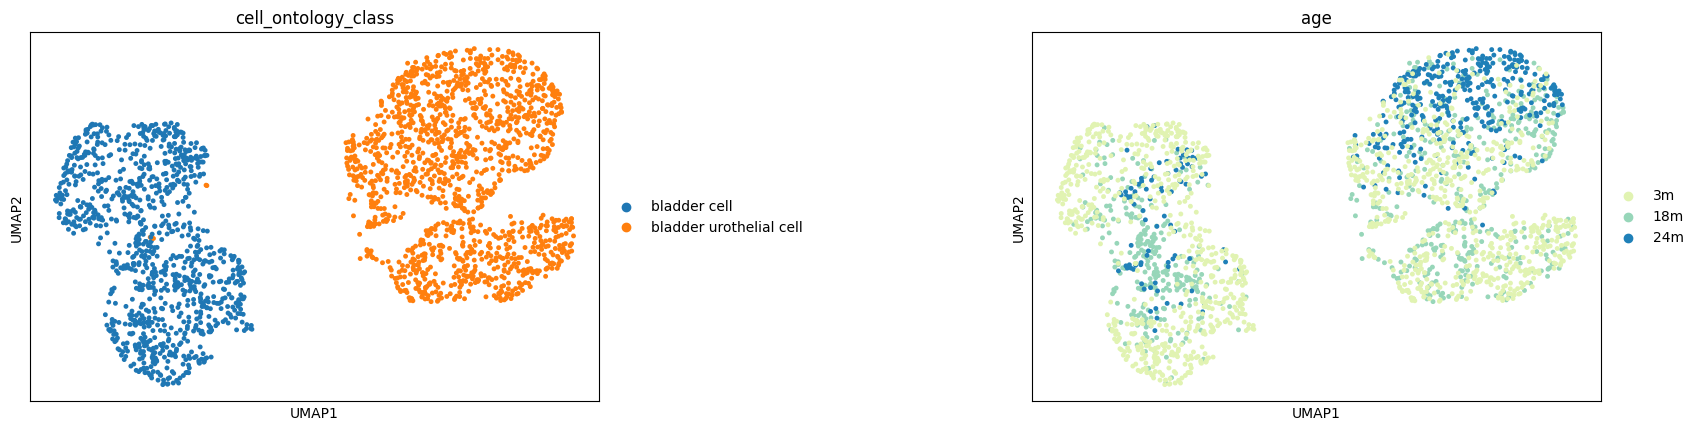

In [2]:
print("Ages in this cohort:", adata_aging.obs['age'].unique().tolist())
print("\nTop 5 cell types found in this tissue:")
print(adata_aging.obs['cell_ontology_class'].value_counts().head(5))
sc.pl.umap(adata_aging, color=['cell_ontology_class', 'age'], wspace=0.6)

Top 10 genes upregulated in 24-month old urothelial cells:
           24m_n       24m_l          24m_p
0         Gm6981   50.602783  1.914751e-120
1         Rpl13a         inf  1.791575e-109
2  A130040M12Rik  368.494171  1.613112e-103
3           Cfl1         inf   2.123605e-89
4           Jund  711.507874   3.398054e-86
5            Aes  340.586517   7.387521e-77
6           Rps3         NaN   8.602963e-73
7          Pebp1         inf   1.330820e-65
8        Arhgdia         inf   3.507555e-65
9          Wdr89   16.543085   3.507555e-65


/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


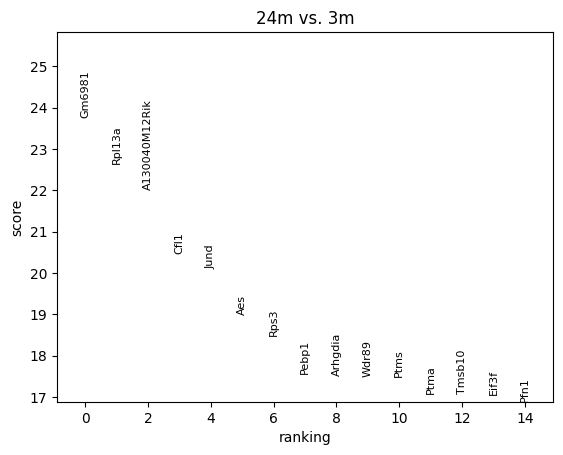

In [4]:
import scanpy as sc
import pandas as pd
urothelial_cells = adata_aging[adata_aging.obs['cell_ontology_class'] == 'bladder urothelial cell'].copy()
sc.pp.normalize_total(urothelial_cells, target_sum=1e4)
sc.pp.log1p(urothelial_cells)
sc.tl.rank_genes_groups(
    urothelial_cells,
    groupby='age',
    groups=['24m'],
    reference='3m',
    method='wilcoxon'
)
result = urothelial_cells.uns['rank_genes_groups']
groups = result['names'].dtype.names
dataframe = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj']}
)
print("Top 10 genes upregulated in 24-month old urothelial cells:")
print(dataframe[['24m_n', '24m_l', '24m_p']].head(10))
sc.pl.rank_genes_groups(urothelial_cells, groups=['24m'], n_genes=15, sharey=False)

In [6]:
!pip install gseapy
import gseapy as gp
import matplotlib.pyplot as plt
top_genes = dataframe['24m_n'].head(50).tolist()
print("Querying the Gene Ontology database...")
enr = gp.enrichr(
    gene_list=top_genes,
    gene_sets='GO_Biological_Process_2025',
    organism='mouse',
    outdir=None
)
results_df = enr.results
print("\nTop 5 Aging Pathways Disrupted:")
print(results_df[['Term', 'Adjusted P-value', 'Overlap']].head())

Querying the Gene Ontology database...

Top 5 Aging Pathways Disrupted:
                                                Term  Adjusted P-value Overlap
0  Positive Regulation of Protein Polymerization ...          0.011996    4/71
1       Regulation of Apoptotic Process (GO:0042981)          0.011996   9/704
2               Cytoplasmic Translation (GO:0002181)          0.015852   4/101
3             Regulation of Translation (GO:0006417)          0.015852   5/201
4                       Gene Expression (GO:0010467)          0.031877   6/381


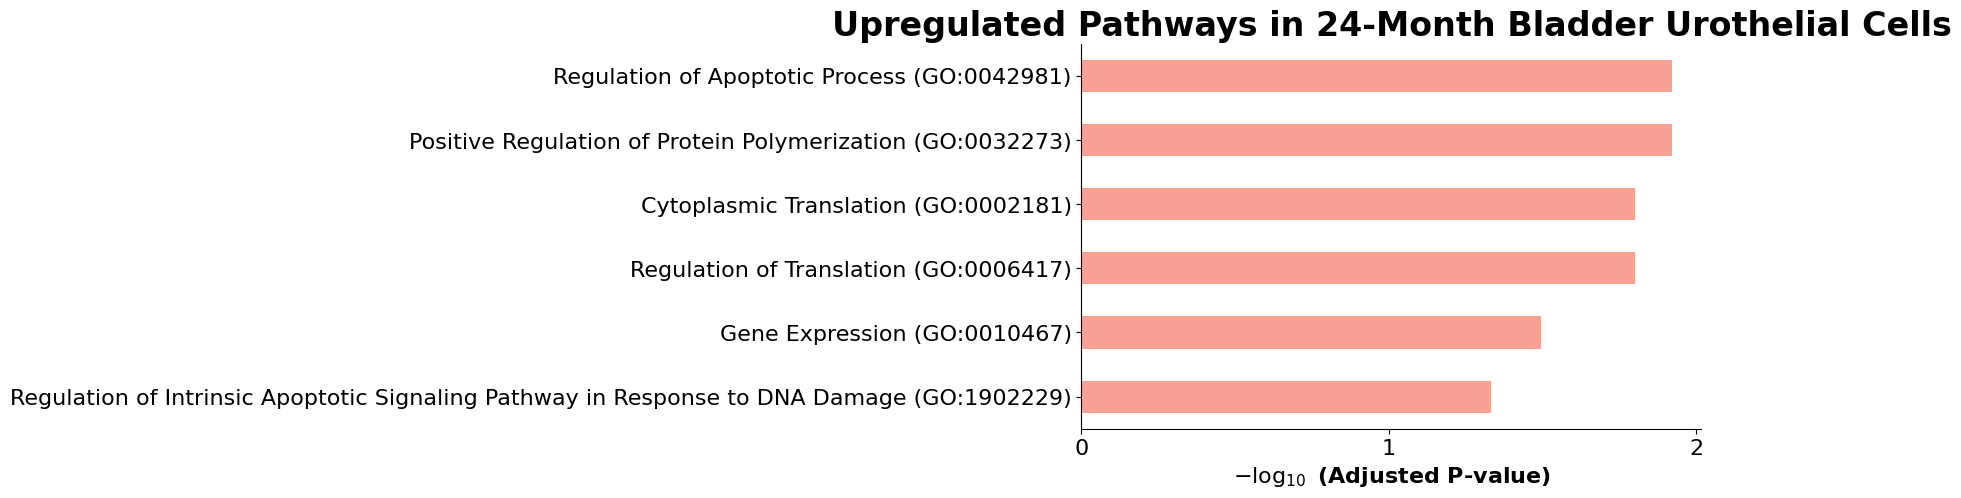

In [7]:
gp.barplot(
    enr.results,
    column="Adjusted P-value",
    title='Upregulated Pathways in 24-Month Bladder Urothelial Cells',
    top_term=10,
    figsize=(8, 5)
)
plt.show()